In [2]:
print("Jupyter working 🚀")

Jupyter working 🚀


In [3]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
import os
os.listdir()

['.DS_Store',
 'creditcard.csv',
 '.ipynb_checkpoints',
 'aAnomaly_Detection.ipynb.ipynb']

In [5]:
from sklearn.ensemble import IsolationForest

# Remove target column
X = df.drop('Class', axis=1)

# Create model
model = IsolationForest(contamination=0.002, random_state=42)

# Train model
model.fit(X)

# Predict anomalies
df['anomaly'] = model.predict(X)

In [6]:
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

In [7]:
from sklearn.metrics import classification_report

print(classification_report(df['Class'], df['anomaly']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807



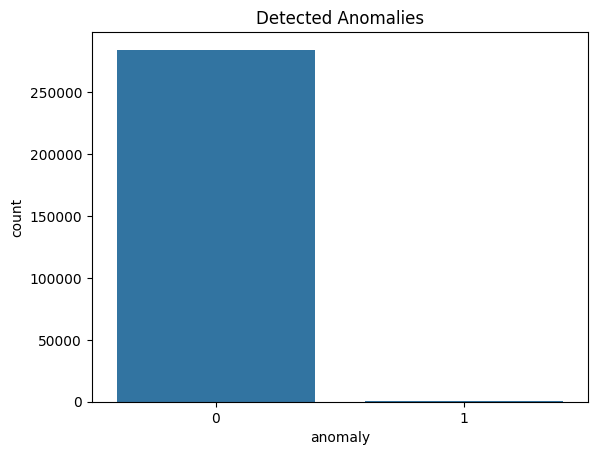

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='anomaly', data=df)
plt.title("Detected Anomalies")
plt.show()

In [9]:
df['Class'].value_counts(), df['anomaly'].value_counts()

(Class
 0    284315
 1       492
 Name: count, dtype: int64,
 anomaly
 0    284237
 1       570
 Name: count, dtype: int64)

In [10]:
df['Class'].value_counts(), df['anomaly'].value_counts()

(Class
 0    284315
 1       492
 Name: count, dtype: int64,
 anomaly
 0    284237
 1       570
 Name: count, dtype: int64)

In [11]:
# Take smaller sample for faster processing
sample_df = df.sample(n=10000, random_state=42)

X_sample = sample_df.drop('Class', axis=1)

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.002)

sample_df['lof_anomaly'] = lof.fit_predict(X_sample)

sample_df['lof_anomaly'] = sample_df['lof_anomaly'].map({1: 0, -1: 1})

In [12]:
from sklearn.metrics import classification_report

print(classification_report(sample_df['Class'], sample_df['lof_anomaly']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9984
           1       0.00      0.00      0.00        16

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       1.00      1.00      1.00     10000



In [15]:
from sklearn.metrics import classification_report

print("Isolation Forest:\n")
print(classification_report(df['Class'], df['anomaly']))

print("\nLOF:\n")
print(classification_report(sample_df['Class'], sample_df['lof_anomaly']))

Isolation Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807


LOF:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9984
           1       0.00      0.00      0.00        16

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       1.00      1.00      1.00     10000



In [16]:
from sklearn.metrics import confusion_matrix

print("Isolation Forest Confusion Matrix:")
print(confusion_matrix(df['Class'], df['anomaly']))

Isolation Forest Confusion Matrix:
[[283883    432]
 [   354    138]]


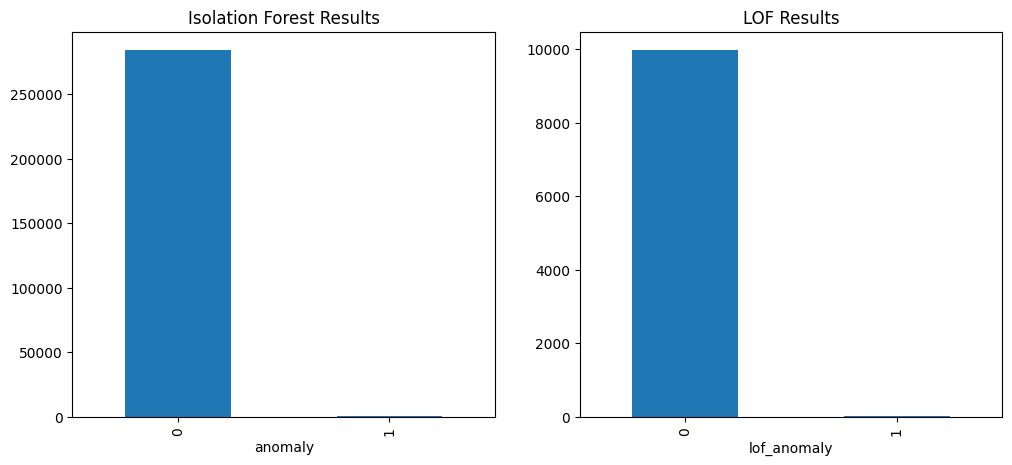

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Isolation Forest
plt.subplot(1,2,1)
df['anomaly'].value_counts().plot(kind='bar')
plt.title("Isolation Forest Results")

# LOF
plt.subplot(1,2,2)
sample_df['lof_anomaly'].value_counts().plot(kind='bar')
plt.title("LOF Results")

plt.show()

## Key Observations

- The dataset is highly imbalanced (very few fraud cases)
- Isolation Forest performs better for global anomaly detection
- LOF works on local density but is computationally expensive
- Precision is more important than accuracy in fraud detection
- Sampling was used to improve performance for LOF

# Anomaly Detection Project

## 1. Data Loading
## 2. Data Exploration
## 3. Model Building
## 4. Model Comparison
## 5. Results & Insights